In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

FILE="data_proc.xlsx"

alerts=pd.read_excel(FILE,sheet_name="Alerts")
sales=pd.read_excel(FILE,sheet_name="Sales")
affil=pd.read_excel(FILE,sheet_name="Affiliation")
alerts["Alert_Date"]=pd.to_datetime(alerts["Alert_Date"])
sales["Prescription_Date"]=pd.to_datetime(sales["Prescription_Date"])

sns.set_theme(style="whitegrid")

Alert Trend Over Time

C:\Users\ACER\AppData\Local\Temp\ipykernel_26384\1754888416.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


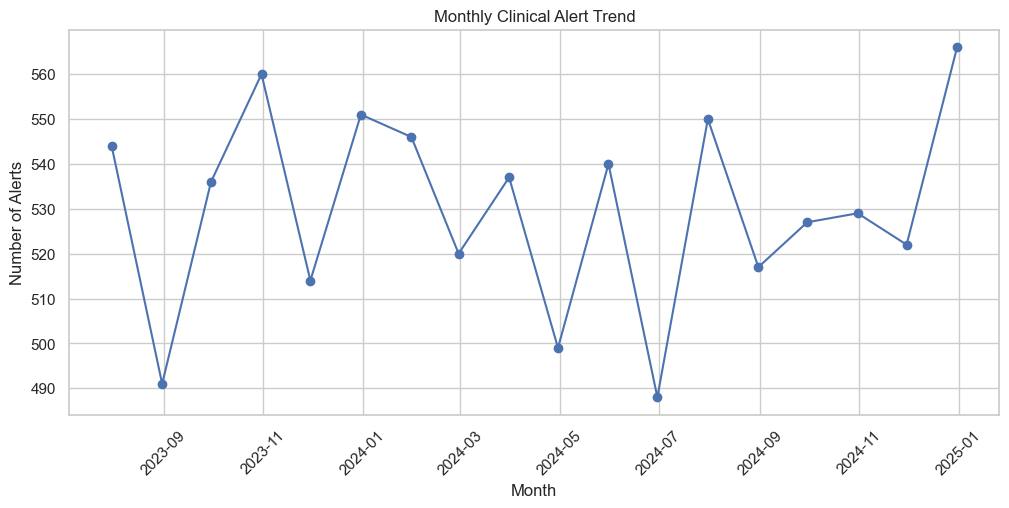

In [ ]:
alert_trend = (
    alerts
    .set_index("Alert_Date")
    .resample("M")
    .size()
)
plt.figure(figsize=(12,5))
plt.plot(
    alert_trend.index,
    alert_trend.values,
    marker="o"
)
plt.title("Monthly Clinical Alert Trend")
plt.xlabel("Month")
plt.ylabel("Number of Alerts")

plt.xticks(rotation=45)
plt.show()

Positive vs Negative Alert Distribution

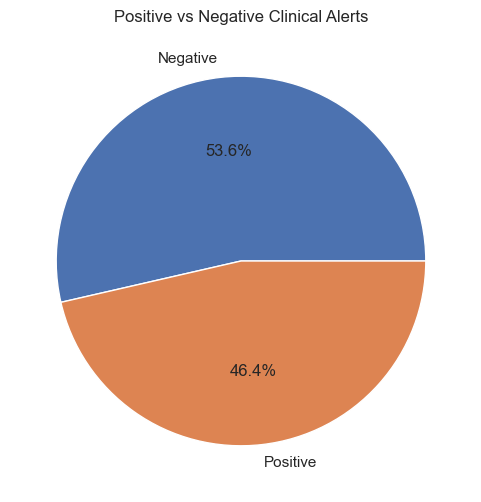

In [ ]:
alert_type=alerts["Lab_Result"].value_counts()
plt.figure(figsize=(6,6))
plt.pie(
    alert_type,
    labels=alert_type.index,
    autopct="%1.1f%%"
)
plt.title("Positive vs Negative Clinical Alerts")
plt.show()

Top 15 Doctors by Alert Volume

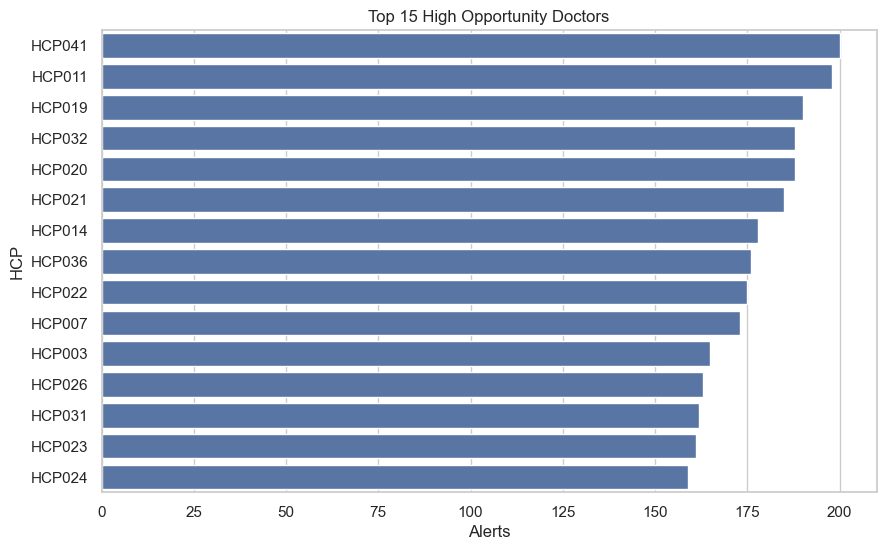

In [ ]:
top_alerts = (
    alerts.groupby("HCP_ID")
    .size()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(10,6))
sns.barplot(
    x=top_alerts.values,
    y=top_alerts.index
)
plt.title("Top 15 High Opportunity Doctors")
plt.xlabel("Alerts")
plt.ylabel("HCP")
plt.show()

Alert vs Prescription Gap Graph

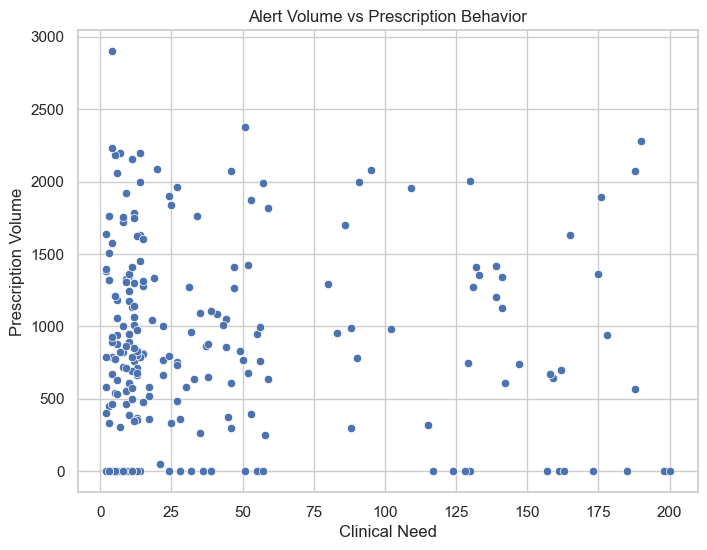

In [ ]:
hcp_alerts=(
    alerts.groupby("HCP_ID")
    .size()
    .reset_index(name="Alerts")
)
hcp_rx = (
    sales.groupby("HCP_ID")
    ["Prescription_Volume"]
    .sum()
    .reset_index(name="Rx")
)
gap = hcp_alerts.merge(
    hcp_rx,
    on="HCP_ID",
    how="left"
)
gap["Rx"]=gap["Rx"].fillna(0)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=gap,
    x="Alerts",
    y="Rx"
)
plt.title("Alert Volume vs Prescription Behavior")
plt.xlabel("Clinical Need")
plt.ylabel("Prescription Volume")

plt.show()

Competitor Leakage Chart

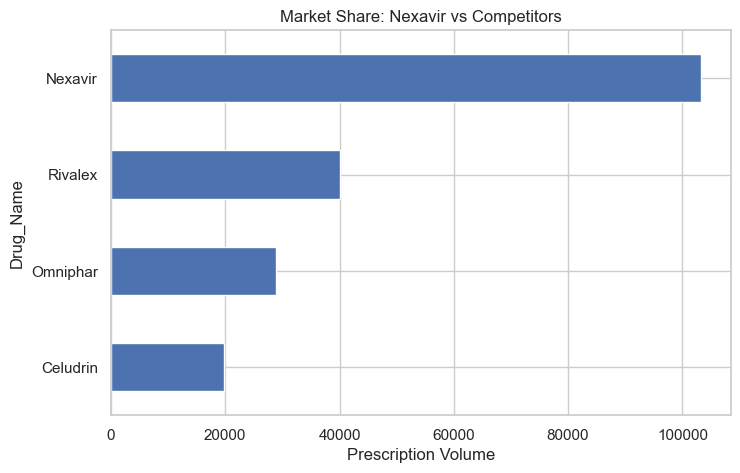

In [ ]:
drug_share = (
    sales.groupby("Drug_Name")
    ["Prescription_Volume"]
    .sum()
    .sort_values()
)
plt.figure(figsize=(8,5))
drug_share.plot(kind="barh")
plt.title("Market Share: Nexavir vs Competitors")
plt.xlabel("Prescription Volume")
plt.show()

Account Opportunity Heatmap

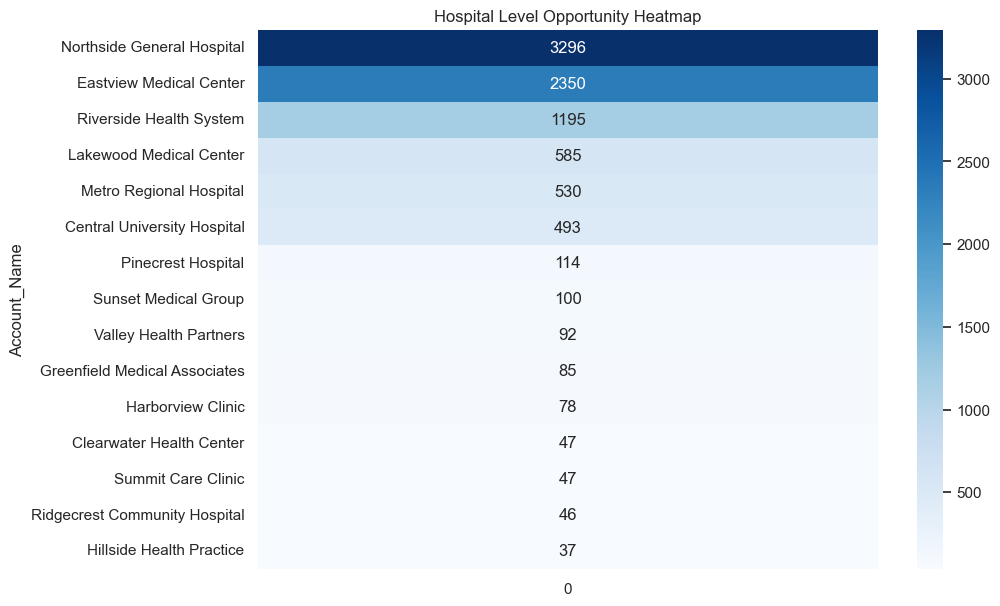

In [ ]:
acc=(
    alerts.merge(
        affil,
        on="HCP_ID"
    )
)
heat = (
    acc.groupby("Account_Name")
    .size()
    .sort_values(ascending=False)
    .head(15)
)
plt.figure(figsize=(10,7))
sns.heatmap(
    heat.to_frame(),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Hospital Level Opportunity Heatmap")
plt.show()

Funnel Chart (Q2)

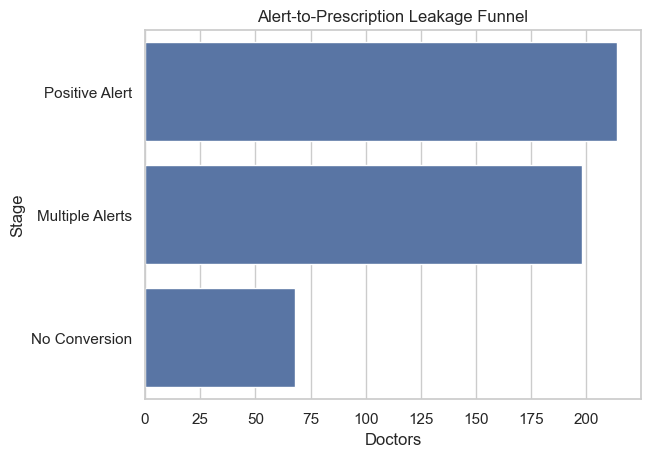

In [ ]:
positive=alerts[
    alerts["Lab_Result"]=="Positive"
]
stage1=positive["HCP_ID"].nunique()


multi=(
    positive.groupby("HCP_ID")
    .size()
)
stage2=(multi>1).sum()
funnel=pd.DataFrame({
     "Stage":[
        "Positive Alert",
        "Multiple Alerts",
        "No Conversion"
    ],
    "Doctors":[
        stage1,
        stage2,
        68
    ]
})
sns.barplot(
    data=funnel,
    x="Doctors",
    y="Stage"
)
plt.title("Alert-to-Prescription Leakage Funnel")
plt.show()

In [ ]:
# DRG001 only
sales_drg001 = sales[sales["Drug_ID"]=="DRG001"]
acc_doc_count = (
    affil
    .groupby(["Account_ID","Account_Name"])
    ["HCP_ID"]
    .nunique()
    .reset_index(name="Total_Doctors")
)
active_docs = (
    sales_drg001
    .merge(
        affil[["HCP_ID","Account_ID"]],
        on="HCP_ID",
        how="inner"
    )
)
acc_active = (
    active_docs
    .groupby("Account_ID")
    ["HCP_ID"]
    .nunique()
    .reset_index(name="Active_Prescribers")
)
acc_volume = (
    active_docs
    .groupby("Account_ID")
    ["Prescription_Volume"]
    .sum()
    .reset_index(name="Total_DRG001_Rx")
)
q5 = (
    acc_doc_count
    .merge(
        acc_active,
        on="Account_ID",
        how="left"
    )
    .merge(
        acc_volume,
        on="Account_ID",
        how="left"
    )
)
q5["Active_Prescribers"] = (
    q5["Active_Prescribers"]
    .fillna(0)
)
q5["Total_DRG001_Rx"] = (
    q5["Total_DRG001_Rx"]
    .fillna(0)
)
q5_active = q5[
    q5["Active_Prescribers"]>0
].copy()
q5_active["Rx_Per_Active_Doctor"] = (
    q5_active["Total_DRG001_Rx"]
    /
    q5_active["Active_Prescribers"]
)
q5_active.head()

,Account_ID,Account_Name,Total_Doctors,Active_Prescribers,Total_DRG001_Rx,Rx_Per_Active_Doctor
0,ACC001,Northside General Hospital,23,15.0,12297.0,819.800000
1,ACC002,Eastview Medical Center,17,14.0,12223.0,873.071429
2,ACC003,Riverside Health System,24,15.0,4947.0,329.800000
3,ACC004,Metro Regional Hospital,17,13.0,5402.0,415.538462
4,ACC005,Lakewood Medical Center,15,12.0,9148.0,762.333333


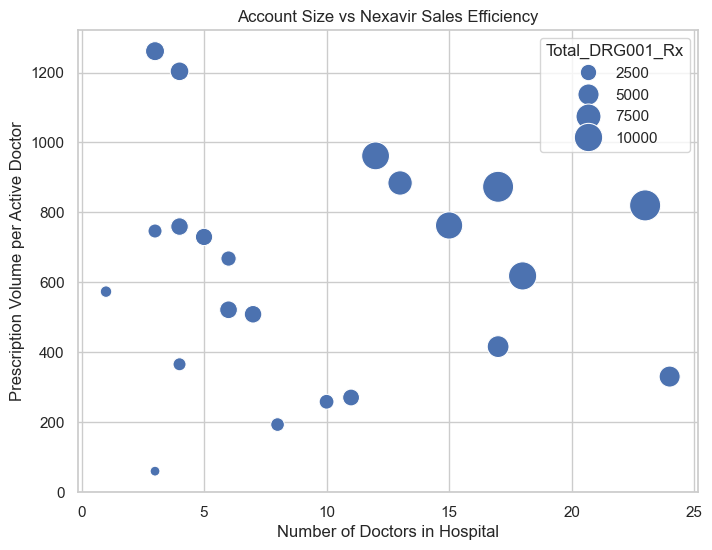

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=q5_active,
    x="Total_Doctors",
    y="Rx_Per_Active_Doctor",
    size="Total_DRG001_Rx",
    sizes=(50,500)
)
plt.title(
"Account Size vs Nexavir Sales Efficiency"
)
plt.xlabel(
"Number of Doctors in Hospital"
)
plt.ylabel(
"Prescription Volume per Active Doctor"
)
plt.show()

In [ ]:
pos_alerts = alerts[
    alerts["Lab_Result"]=="Positive"
]
first_positive = (
    pos_alerts
    .groupby("HCP_ID")["Alert_Date"]
    .min()
    .reset_index(name="First_Positive_Date")
)
sales_drg001 = sales[
    sales["Drug_ID"]=="DRG001"
]

results=[]

for _,row in first_positive.iterrows():
    
    hcp=row["HCP_ID"]
    date=row["First_Positive_Date"]
    before_start = date - pd.Timedelta(days=90)
    before_end   = date
    after_start=date
    after_end=date + pd.Timedelta(days=90)
    hcp_sales = sales_drg001[
        sales_drg001["HCP_ID"]==hcp
    ]
    pre = (
        hcp_sales[
            (hcp_sales["Prescription_Date"]>=before_start)
            &
            (hcp_sales["Prescription_Date"]<before_end)
        ]
        ["Prescription_Volume"]
        .sum()
    )
    post = (
        hcp_sales[
            (hcp_sales["Prescription_Date"]>after_start)
            &
            (hcp_sales["Prescription_Date"]<=after_end)
        ]
        ["Prescription_Volume"]
        .sum()
    )
    if pre==0 and post>0:
        lift=None
        segment="New Starter"
        
    elif pre>0:
        lift=((post-pre)/pre)*100
        
        if lift>=20:
            segment="Grower"
        else:
            segment="Non Responder"       
    else:
        lift=0
        segment="Non Responder"
    results.append(
        {
            "HCP_ID":hcp,
            "Pre_90d_Rx":pre,
            "Post_90d_Rx":post,
            "Lift_%":lift,
            "Segment":segment
        }
    )
q6=pd.DataFrame(results)
q6.head()

,HCP_ID,Pre_90d_Rx,Post_90d_Rx,Lift_%,Segment
0,HCP001,0,0,0.0,Non Responder
1,HCP002,0,0,0.0,Non Responder
2,HCP003,0,170,NaN,New Starter
3,HCP004,0,145,NaN,New Starter
4,HCP005,0,58,NaN,New Starter


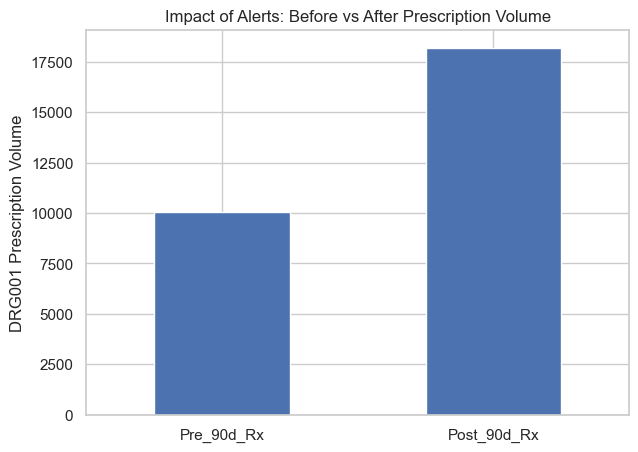

In [ ]:
lift_compare = (
    q6[
        [
            "Pre_90d_Rx",
            "Post_90d_Rx"
        ]
    ]
    .sum()
)
lift_compare.plot(
    kind="bar",
    figsize=(7,5)
)
plt.title(
"Impact of Alerts: Before vs After Prescription Volume"
)
plt.ylabel(
"DRG001 Prescription Volume"
)
plt.xticks(rotation=0)
plt.show()

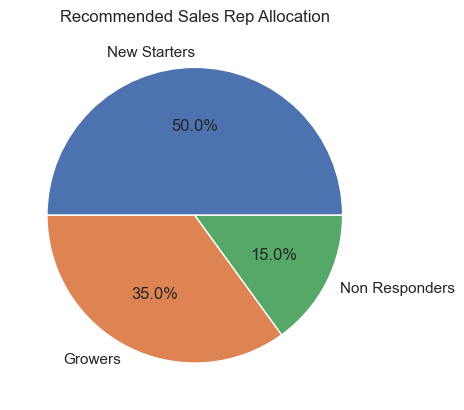

In [ ]:
allocation = pd.Series({
    "New Starters":50,
    "Growers":35,
    "Non Responders":15
})
plt.pie(
    allocation,
    labels=allocation.index,
    autopct="%1.1f%%"
)
plt.title(
"Recommended Sales Rep Allocation"
)
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_26384\1796958828.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(


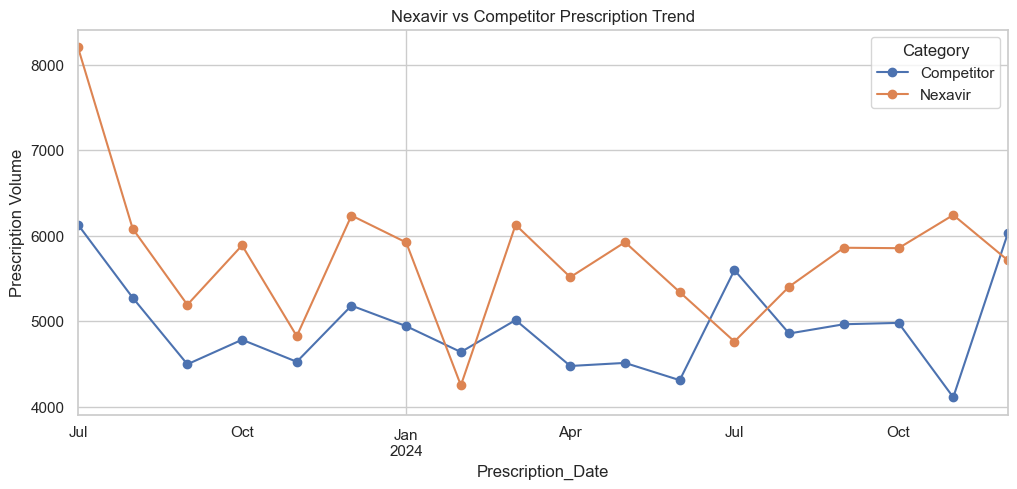

In [ ]:
temp=sales.copy()

temp["Category"] = temp["Drug_ID"].apply(
    lambda x:
    "Nexavir"
    if x=="DRG001"
    else "Competitor"
)
trend = (
    temp
    .groupby([
        pd.Grouper(
            key="Prescription_Date",
            freq="M"
        ),
        "Category"
    ])
    ["Prescription_Volume"]
    .sum()
    .unstack()
)
trend.plot(
    figsize=(12,5),
    marker="o"
)
plt.title(
"Nexavir vs Competitor Prescription Trend"
)
plt.ylabel(
"Prescription Volume"
)
plt.show()